In [1]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import tensorflow.keras.layers as L
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K

2025-11-30 10:36:57.289906: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764499017.475469      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764499017.525696      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

## Paths

In [2]:
KAGGLE_EXT = "../input/dataset-2/"
IMAGE_DIR = f"{KAGGLE_EXT}LabelStudioToMask_FINAL/images"
MASK_DIR = f"{KAGGLE_EXT}LabelStudioToMask_FINAL/masks"
sample_img = "/kaggle/input/dataset-2/LabelStudioToMask_FINAL/images/RVG_1.png"
sample_mask = "/kaggle/input/dataset-2/LabelStudioToMask_FINAL/masks/RVG_1_mask.png"

## Loading the images

In [3]:
TARGET_SIZE = (790, 1100)
def load_image(image_path):
    img_obj = tf.io.read_file(image_path)
    image = tf.io.decode_png(img_obj, channels=1)
    image = tf.image.resize(image, TARGET_SIZE, method='bilinear')
    image = tf.pad(image, [[5,5],[2,2],[0,0]])   # pad H,W
    image = tf.cast(image, tf.float32) / 255.0 # Normalization
    return image

s = load_image(sample_img)
print("Sample image shape: ", s.shape)

Sample image shape:  (800, 1104, 1)


I0000 00:00:1764499032.616593      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [4]:
def load_mask(mask_path):
    """We have 4 classes."""
    mask = tf.io.decode_png(tf.io.read_file(mask_path), channels=1)
    mask = tf.image.resize(mask, TARGET_SIZE, method='nearest')
    mask = tf.pad(mask, [[5,5],[2,2],[0,0]])   # pad H,W
    mask = tf.cast(mask, tf.int32)  
    mask = mask // 85   # 0→0, 85→1, 170→2, 255→3
    return mask

s1 = load_mask(sample_mask)
print("Sample mask shape: ", s1.shape)

Sample mask shape:  (800, 1104, 1)


In [5]:
def load_pair(image_path):
    """Extract name: RVG_1.png → RVG_1_mask.png"""
    filename = tf.strings.split(image_path, '/')[-1]   # RVG_1.png
    noext = tf.strings.regex_replace(filename, ".png", "")
    mask_name = noext + "_mask.png"
    mask_path = tf.strings.join([MASK_DIR, "/", mask_name])

    return load_image(image_path), load_mask(mask_path)
    
sample_pair = load_pair(sample_img)
print("Shapes of sample image: ", sample_pair[0].shape," And sample mask", sample_pair[1].shape)

Shapes of sample image:  (800, 1104, 1)  And sample mask (800, 1104, 1)


In [6]:
image_files = sorted([IMAGE_DIR + "/" + f for f in os.listdir(IMAGE_DIR)])
ds = tf.data.Dataset.from_tensor_slices(image_files)
ds = ds.map(load_pair, num_parallel_calls=4)

#Splits
dataset_size = len(image_files)
train_size = int(0.7 * dataset_size)      # 61 for 88 images
val_size   = int(0.1 * dataset_size)     # 13 for 88 images
test_size  = dataset_size - train_size - val_size   # 14 for 88 images

BATCH_SIZE = 4

train_data = ds.take(train_size).batch(BATCH_SIZE)
val_data   = ds.skip(train_size).take(val_size).batch(BATCH_SIZE)
test_data  = ds.skip(train_size + val_size).take(test_size).batch(BATCH_SIZE)

print("Size of train data : ", train_data.cardinality().numpy())
print("Size of validation data : ", val_data.cardinality().numpy())
print("Size of test data : ", test_data.cardinality().numpy())
print("Total data size : ", train_data.cardinality().numpy() + val_data.cardinality().numpy() + test_data.cardinality().numpy())

Size of train data :  16
Size of validation data :  2
Size of test data :  5
Total data size :  23


## Defining the all blocks of the attention U-net block

In [7]:
def conv_block(x, num_filters):

    x = L.Conv2D(num_filters, kernel_size = (3, 3), padding="same")(x)
    x = L.BatchNormalization()(x)
    x = L.Activation("relu")(x)

    x = L.Conv2D(num_filters, kernel_size = (3, 3), padding="same")(x)
    x = L.BatchNormalization()(x)
    x = L.Activation("relu")(x)

    return x

In [8]:
def encoder_block(x, num_filters):
    x = conv_block(x, num_filters)
    p = L.MaxPool2D((2, 2), padding="same")(x)
    return x, p

In [9]:
def attention_gate(g, s, num_filters):

    wg = L.Conv2D(num_filters, 1, padding="same")(g)
    wg = L.BatchNormalization()(wg)

    ws = L.Conv2D(num_filters, 1, padding="same")(s)
    ws = L.BatchNormalization()(ws)

    out = L.Activation("relu")(wg + ws)
    out = L.Conv2D(num_filters, 1, padding="same")(out)
    out = L.Activation("sigmoid")(out)

    return out * ws

In [10]:
def decoder_block(x, s, num_filters):
    x_up = L.UpSampling2D((2,2), interpolation="nearest")(x)
    
    # Now x_up matches s spatially
    s_att = attention_gate(x_up, s, num_filters)

    x = L.Concatenate()([x_up, s_att])
    x = conv_block(x, num_filters)
    return x


# Defining custom loss functions

In [11]:
def dice_loss(y_true, y_pred, smooth=1e-6):
    # y_true: (B,H,W,1) sparse integers
    # one-hot encode -> (B,H,W,4)
    y_true = tf.cast(y_true, tf.int32)
    y_true = tf.squeeze(y_true, axis=-1)
    y_true = tf.one_hot(y_true, depth=4)   # num_classes = 4
    y_true = tf.cast(y_true, tf.float32)

    # y_pred already softmax -> (B,H,W,4)
    y_pred = tf.cast(y_pred, tf.float32)

    # Dice numerator & denominator
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2])
    union = tf.reduce_sum(y_true + y_pred, axis=[1, 2])

    dice = (2.0 * intersection + smooth) / (union + smooth)

    # return mean Dice loss across batch & classes
    return 1 - tf.reduce_mean(dice)




def combined_loss(y_true, y_pred):
    scce = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    dloss = dice_loss(y_true, y_pred)
    return scce + dloss


In [12]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    mode='min',
    verbose=1
)


# Defining the entirety of the U-net

In [13]:
def attention_unet(input_shape, init_filters=32):
    #inputs
    inputs = L.Input((None, None, 1))

    # Encoder
    s1, p1 = encoder_block(inputs, init_filters)
    s2, p2 = encoder_block(p1, init_filters * 2)
    s3, p3 = encoder_block(p2, init_filters * 4)
    s4, p4 = encoder_block(p3, init_filters * 8)

    # Bridge
    b1 = conv_block(p4, 512)
    # print("Shape of b1, s4: ", b1.shape, s4.shape)

    # Decoder
    d1 = decoder_block(b1, s4, init_filters * 8)
    d2 = decoder_block(d1, s3, init_filters * 4)
    d3 = decoder_block(d2, s2, init_filters * 2)
    d4 = decoder_block(d3, s1, init_filters)

    # Outputs 
    outputs = L.Conv2D(4, 1, padding="same", activation="softmax")(d4)

    # Model 
    model = Model(inputs, outputs, name="Attention-Unet")
    return model

In [14]:
input_shape = (790, 1100, 1)
model = attention_unet(input_shape, init_filters = 32)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("model.output_shape:", model.output_shape)

model.summary()

model.output_shape: (None, None, None, 4)


Model: "Attention-Unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, None,      │        320 │ input_layer[0][0] │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, None,      │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, None,      │      9,248 │ activation[0][0]  │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, None,      │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, None,      │     18,496 │ max_pooling2d[0]… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, None,      │     36,928 │ activation_2[0][… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, None,      │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, None,      │     73,856 │ max_pooling2d_1[… │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        512 │ conv2d_4[0][0]  

 Total params: 8,211,396 (31.32 MB)

 Trainable params: 8,203,588 (31.29 MB)

 Non-trainable params: 7,808 (30.50 KB)

## Model training

In [15]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    # callbacks=[early_stop]
)

Epoch 1/20


I0000 00:00:1764499051.013815     108 service.cc:148] XLA service 0x7fc2c8003a60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764499051.014659     108 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
W0000 00:00:1764499052.396447     108 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1764499053.412467     108 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1764499055.090039     108 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764499055.262637     108 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764499056.493346     1

15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 677ms/step - accuracy: 0.3837 - loss: 1.4209

W0000 00:00:1764499126.373986     106 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
E0000 00:00:1764499127.985196     106 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764499128.157517     106 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764499128.565227     106 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764499128.741503     106 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:176449

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3907 - loss: 1.4120   

W0000 00:00:1764499153.493314     106 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


16/16 ━━━━━━━━━━━━━━━━━━━━ 120s 3s/step - accuracy: 0.3968 - loss: 1.4042 - val_accuracy: 0.2801 - val_loss: 1.4175
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 737ms/step - accuracy: 0.6469 - loss: 1.0648 - val_accuracy: 0.2801 - val_loss: 1.4519
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 735ms/step - accuracy: 0.7061 - loss: 0.9324 - val_accuracy: 0.2801 - val_loss: 1.4819
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 737ms/step - accuracy: 0.7289 - loss: 0.8598 - val_accuracy: 0.2801 - val_loss: 1.5121
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 738ms/step - accuracy: 0.7410 - loss: 0.8150 - val_accuracy: 0.2801 - val_loss: 1.5486
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 738ms/step - accuracy: 0.7597 - loss: 0.7722 - val_accuracy: 0.2801 - val_loss: 1.5867
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 740ms/step - accuracy: 0.7702 - loss: 0.7396 - val_accuracy: 0.2801 - val_loss: 1.6182
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 739ms/step - accuracy: 0.7766 - loss: 0.7142 - val_accuracy: 0.2801 

## Plotting loss curves

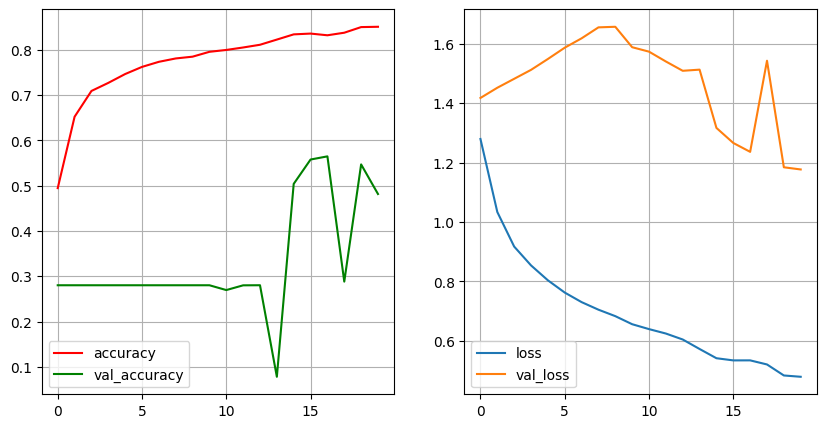

In [16]:
plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy', color='r')
plt.plot(history.history['val_accuracy'], label='val_accuracy', color='g')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.grid()

plt.show()

## Testing

In [18]:
results = model.evaluate(test_data)
print("Test metrics:", results)


4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.4989 - loss: 1.1501

W0000 00:00:1764499407.880489     108 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
E0000 00:00:1764499408.290255     108 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764499408.462721     108 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764499409.224149     108 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764499409.415795     108 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:176449

5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.5039 - loss: 1.1489 
Test metrics: [1.1464570760726929, 0.5138607025146484]


## Testing with 1 image

In [22]:
TEST_IMAGE = "/kaggle/input/dataset-2/LabelStudioToMask_FINAL/images/RVG_109.png"
TEST_MASK = "/kaggle/input/dataset-2/LabelStudioToMask_FINAL/masks/RVG_109_mask.png"

In [23]:
img = load_image(TEST_IMAGE)   # applies padding/resize etc.
img = tf.expand_dims(img, axis=0)  # shape: (1, H, W, 1)

pred = model.predict(img)
print(pred.shape)   # (1, H, W, 4)

label_map = tf.argmax(pred, axis=-1)   # shape (1, H, W)
label_map = label_map[0]               # remove batch axis

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
(1, 800, 1104, 4)


In [24]:
gt_mask = load_mask(TEST_MASK)
gt_mask = tf.squeeze(gt_mask).numpy()


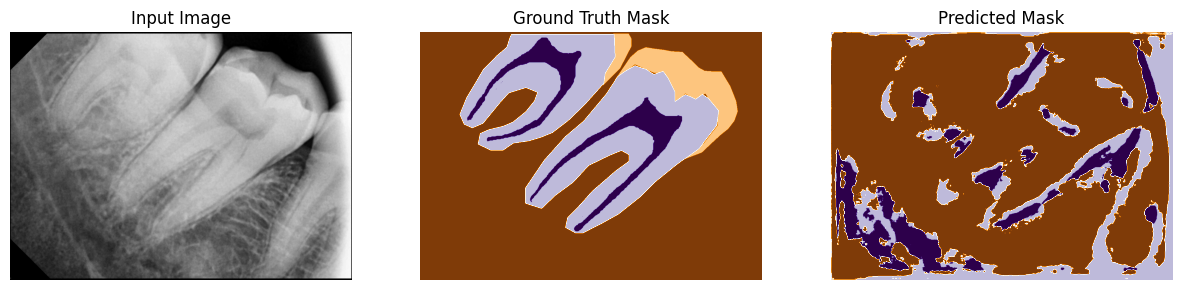

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Input Image")
plt.imshow(tf.squeeze(img[0]), cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Ground Truth Mask")
plt.imshow(gt_mask, cmap='PuOr')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Predicted Mask")
plt.imshow(label_map, cmap='PuOr')
plt.axis('off')

plt.show()
